# 09 - DeepAR benchmark products (`sktime/pytorch-forecasting`)

This notebook inspects and adapts the local `sktime/pytorch-forecasting` repository to benchmark the `DeepAR` implementation on the official three-product M5 benchmark.

Benchmark products:
- `FOODS_3_228_CA_1_validation` (`high_demand_stable`)
- `FOODS_2_044_CA_3_validation` (`intermittent`)
- `HOBBIES_1_133_CA_4_validation` (`low_volume`)

Official protocol:
- `MAX_DAYS = 365`
- `CONTEXT_LENGTH = 28`
- `VAL_DAYS = 28`
- `TEST_DAYS = 28`
- train = `309`, validation = `28`, fit = `337`, test = final `28`


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'gnn_model_comparison':
    ROOT = ROOT.parents[1]
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

VENV_SITE_PACKAGES = ROOT / '.venv' / 'Lib' / 'site-packages'
if VENV_SITE_PACKAGES.exists() and str(VENV_SITE_PACKAGES) not in sys.path:
    sys.path.insert(0, str(VENV_SITE_PACKAGES))

REPO_ROOT = ROOT / 'pytorch-forecasting-main' / 'pytorch-forecasting-main'
OUT_DIR = ROOT / 'reports' / 'gnn_benchmarks' / 'pytorch_forecasting_deepar_impl1'
REPO_ROOT, OUT_DIR, VENV_SITE_PACKAGES


(WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/pytorch-forecasting-main/pytorch-forecasting-main'),
 WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/pytorch_forecasting_deepar_impl1'),
 WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/.venv/Lib/site-packages'))

## Useful repo files identified

- `examples/ar.py`: end-to-end DeepAR example
- `pytorch_forecasting/models/deepar/_deepar.py`: DeepAR implementation
- `pytorch_forecasting/data/timeseries/_timeseries.py`: `TimeSeriesDataSet`
- `README.md`: training pattern with Lightning + `from_dataset()`

Reused directly:
- `TimeSeriesDataSet`
- `DeepAR.from_dataset(...)`
- Lightning trainer-based fit loop
- `predict()` pipeline

Adapted only where necessary:
- M5 single-series dataframe builder
- fixed `309 / 28 / 28` split
- validation for early stopping, then refit on `337` days
- final benchmark metrics and plots


In [3]:
from src.experiments.run_pytorch_forecasting_deepar_benchmark import main

main()


C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\pytorch-forecasting-main\pytorch-forecasting-main\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\pytorch-forecasting-main\pytorch-forecasting-main\pytorch_forecasting\data\encoders.py:402: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\pytorch-forecasting-main\pytorch-forecasting-main\pytorch_forecasting\data\encoders.py:402: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/pro

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\rich\live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\utilities
\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\trainer\c
onnectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve 
performance.

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\trainer\c
onnectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve 
performance.

...

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinst

C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\loops\tra
ining_epoch_loop.py:500: ReduceLROnPlateau conditioned on metric val_loss which is not available but strict is set 
to `False`. Skipping learning rate update.

`Trainer.fit` stopped: `max_epochs=10` reached.


C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\pytorch-forecasting-main\pytorch-forecasting-main\pytorch_forecasting\data\encoders.py:402: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\.venv\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\b

[RUN] HOBBIES_1_133_CA_4_validation | final_loss=0.366778 | mae=0.017602 | vr=0.000000 | flat=flat
[OK] Saved metrics -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\pytorch_forecasting_deepar_impl1\metrics.csv
[OK] Saved training summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\pytorch_forecasting_deepar_impl1\training_summary.csv
[OK] Saved summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\pytorch_forecasting_deepar_impl1\summary.csv
[OK] Saved predictions -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\pytorch_forecasting_deepar_impl1\predictions.csv


In [4]:
import pandas as pd

training_summary_df = pd.read_csv(OUT_DIR / 'training_summary.csv')
metrics_df = pd.read_csv(OUT_DIR / 'metrics.csv')
summary_df = pd.read_csv(OUT_DIR / 'summary.csv')

training_summary_df


,series_id,benchmark_label,model,phase1_epochs,phase1_val_loss,refit_epochs,final_loss,context_length,train_days,fit_days
0,FOODS_3_228_CA_1_validation,high_demand_stable,PyTorchForecastingDeepAR,7,4.385026,8,1.554730,28,309,337
1,FOODS_2_044_CA_3_validation,intermittent,PyTorchForecastingDeepAR,7,41.913837,8,0.240630,28,309,337
2,HOBBIES_1_133_CA_4_validation,low_volume,PyTorchForecastingDeepAR,10,-2.766533,11,0.366778,28,309,337


In [5]:
summary_df


,series_id,benchmark_label,final_loss,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,1.554730,3.036080,3.645430,2.227221,2.781820,0.800634,0.502705,0.518519,0.718358,1.0,non-flat
1,FOODS_2_044_CA_3_validation,intermittent,0.240630,1.060929,1.378756,0.278514,1.456863,0.191174,0.462561,0.444444,0.607884,0.0,non-flat
2,HOBBIES_1_133_CA_4_validation,low_volume,0.366778,0.017602,0.017609,0.000509,0.000000,0.000000,NaN,0.000000,0.380101,1.0,flat


WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/pytorch_forecasting_deepar_impl1/figures/high_demand_stable_FOODS_3_228_CA_1_validation_real_vs_predicted.png')

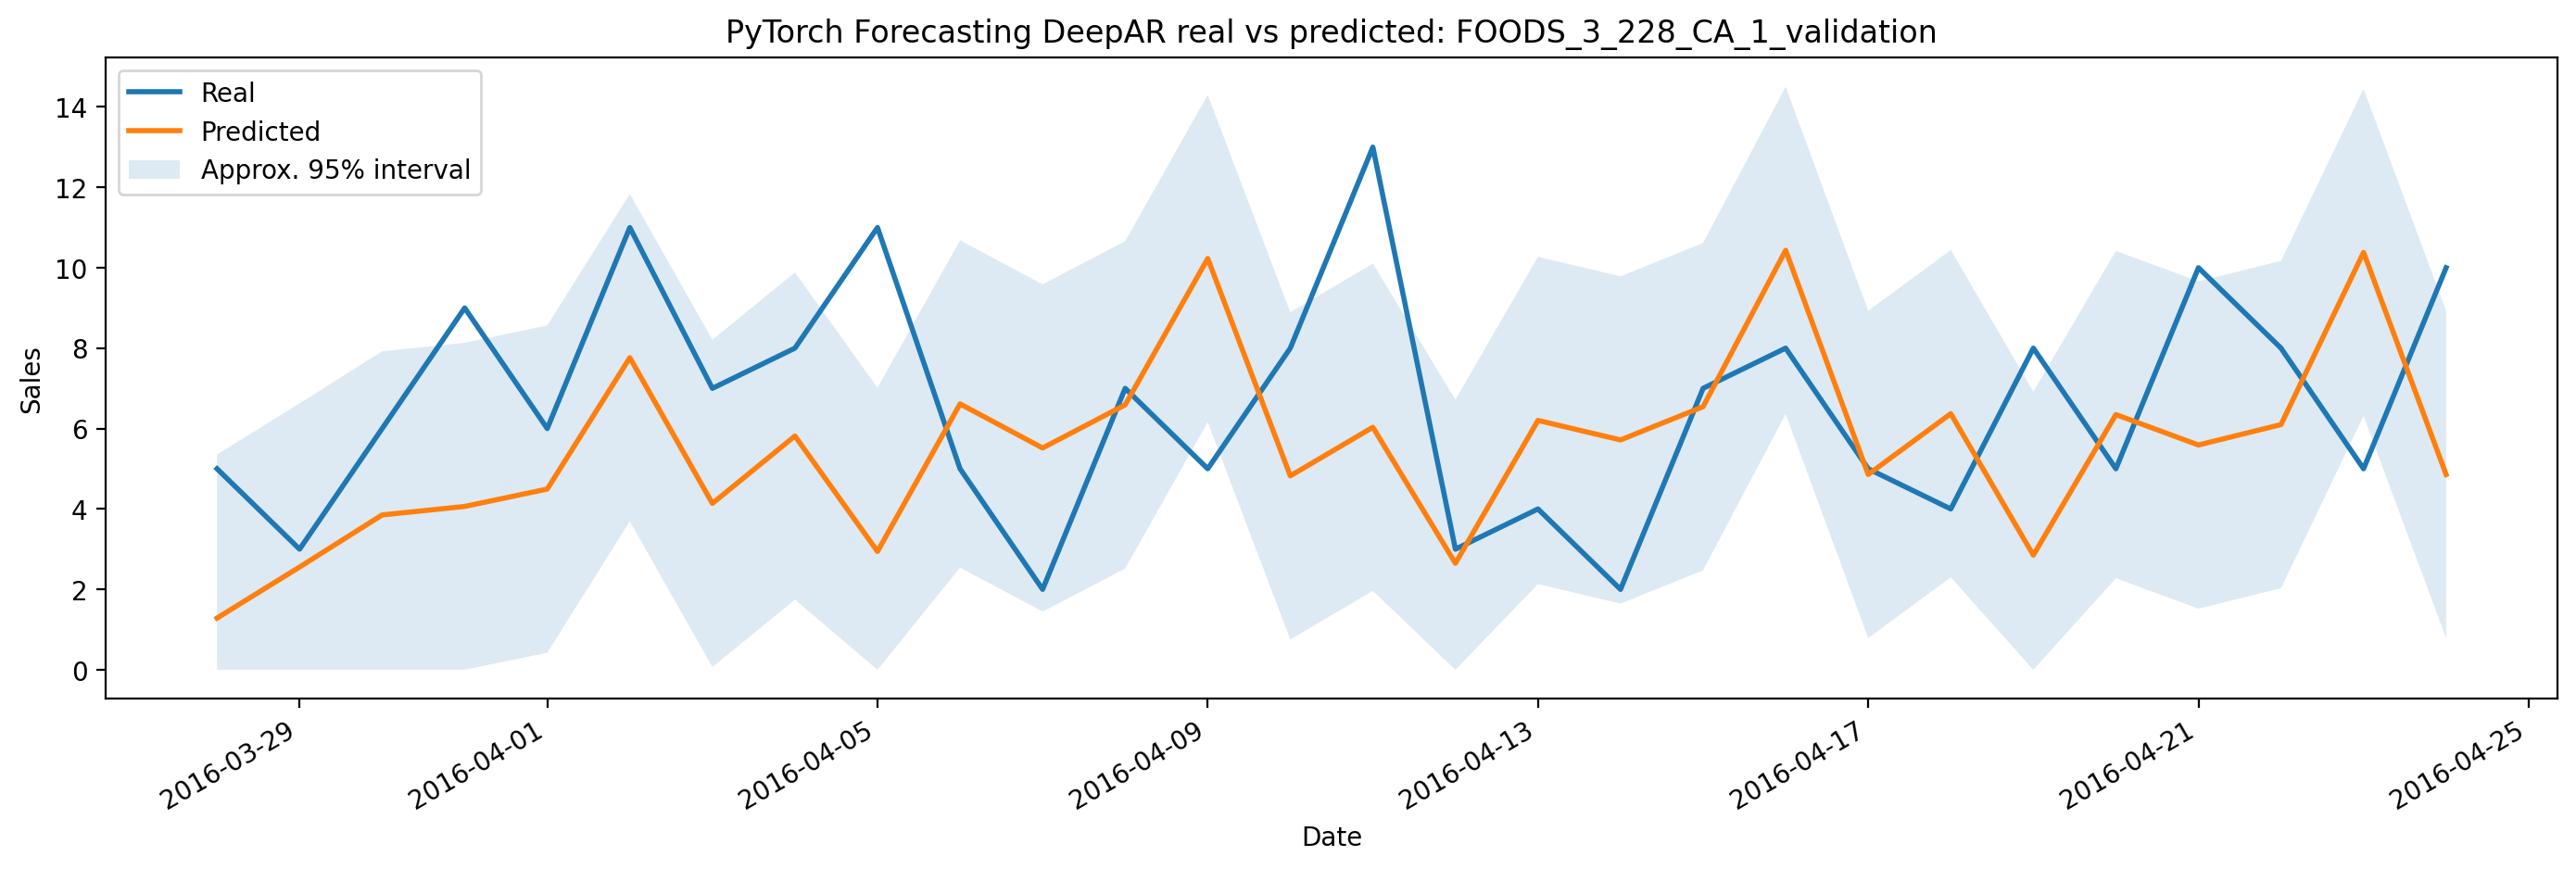

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/pytorch_forecasting_deepar_impl1/figures/intermittent_FOODS_2_044_CA_3_validation_real_vs_predicted.png')

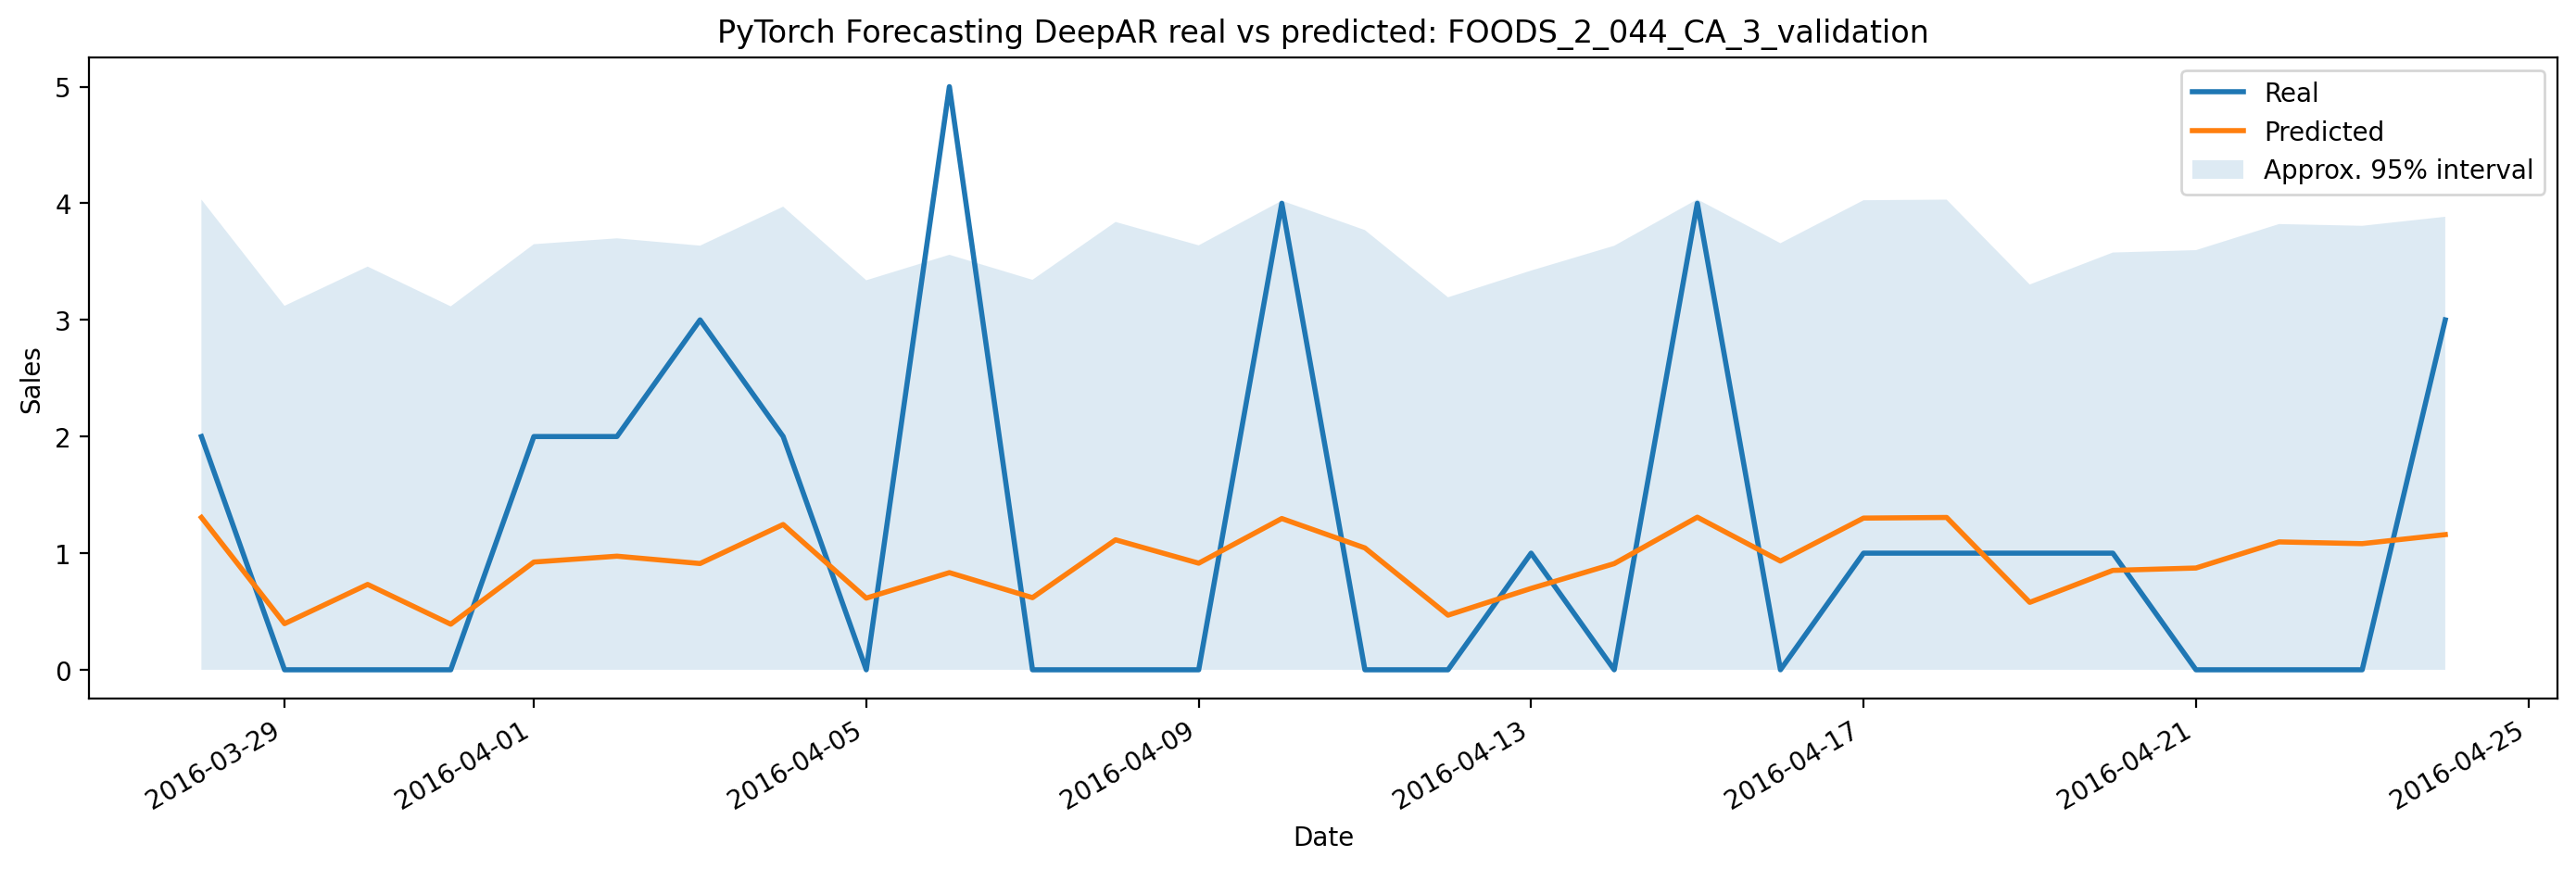

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/pytorch_forecasting_deepar_impl1/figures/low_volume_HOBBIES_1_133_CA_4_validation_real_vs_predicted.png')

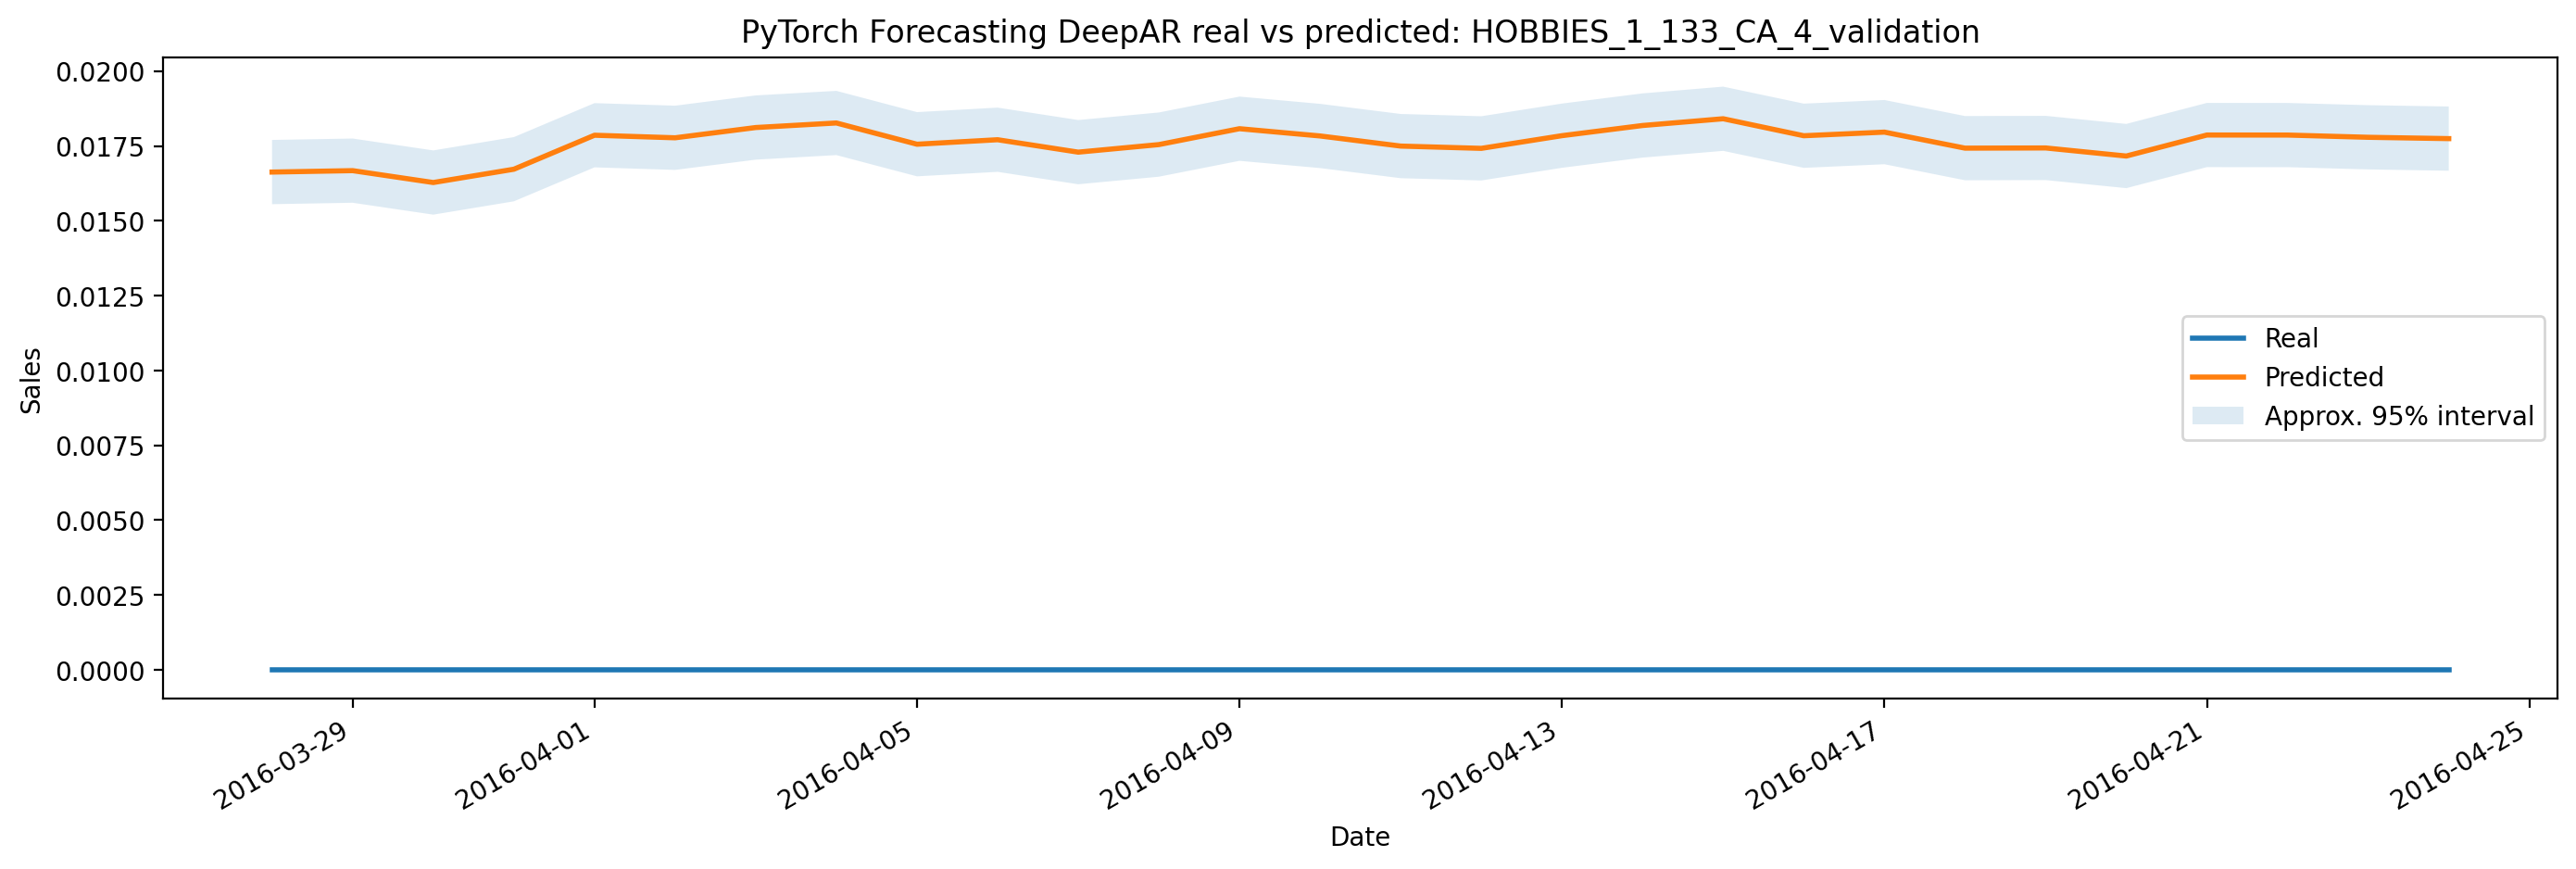

In [6]:
from IPython.display import Image, display

for label, series_id in [
    ('high_demand_stable', 'FOODS_3_228_CA_1_validation'),
    ('intermittent', 'FOODS_2_044_CA_3_validation'),
    ('low_volume', 'HOBBIES_1_133_CA_4_validation'),
]:
    path = OUT_DIR / 'figures' / f'{label}_{series_id}_real_vs_predicted.png'
    display(path)
    display(Image(filename=str(path)))
